# Indian Used Car Price Prediction-
By Manav Desai(23ucs639) , Tushar Madan(23ucs725)

The goal of this project is to predict the prices of used cars in major Indian metro cities by analyzing key features such as the car’s brand, model, variant, fuel type, quality score, and several other factors.

### About the Dataset
We're using the "Indian IT Cities Used Car Dataset 2023", a rich and detailed collection of used car listings from major metro cities across India. This dataset includes a wide variety of information like car models, variants, price points, fuel types, kilometers driven, body style, transmission, ownership history, and manufacturing details. It also covers dealership locations, warranty status, color, whether a CNG kit is installed, and even a quality score to indicate the condition of the car.

This data provides a strong foundation to explore market trends, understand what factors influence used car prices, and build a reliable price prediction model.

### Data Dictionary
| Column Name | Description |
| --- | --- |
|ID|Unique ID for each listing|
|Company|Name of the car manufacturer|
|Model|Name of the car model|
|Variant|Name of the car variant|
|Fuel Type|Fuel type of the car|
|Color|Color of the car|
|Killometer|Number of kilometers driven by the car|
|Body Style|Body style of the car|
|Transmission Type|Transmission type of the car|
|Manufacture Date|Manufacture date of the car|
|Model Year|Model year of the car|
|CngKit|Whether the car has a CNG kit or not|
|Price|Price of the car|
|Owner Type|Number of previous owners of the car|
|Dealer State|State in which the car is being sold|
|Dealer Name|Name of the dealer selling the car|
|City|City in which the car is being sold|
|Warranty|Warranty offered by the dealer|
|Quality Score|Quality score of the car|

In [59]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [60]:
#Loading the dataset
df = pd.read_csv('usedCars.csv')
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


## Data Preprocessing Part 1

In [61]:
#Shape of the dataset
df.shape

(1064, 19)

In [62]:
#colums in the dataset
df.columns

Index(['Id', 'Company', 'Model', 'Variant', 'FuelType', 'Colour', 'Kilometer',
       'BodyStyle', 'TransmissionType', 'ManufactureDate', 'ModelYear',
       'CngKit', 'Price', 'Owner', 'DealerState', 'DealerName', 'City',
       'Warranty', 'QualityScore'],
      dtype='object')

In [63]:
#dropping column ID, as it is a identifier and not required for analysis
df.drop('Id',axis=1,inplace=True)

In [64]:
#Column Data Types
df.dtypes

,0
Company,object
Model,object
Variant,object
FuelType,object
Colour,object
Kilometer,int64
BodyStyle,object
TransmissionType,object
ManufactureDate,object
ModelYear,int64


To type cast the Price column to float

In [65]:
def convert_amount(amount_str):
    if "Lakhs" in amount_str:
        return float(amount_str.replace(' Lakhs', '').replace(',', '')) * 100000
    else:
        return float(amount_str.replace(',', ''))

df['Price'] = df['Price'].apply(convert_amount)

In [66]:
#Checking for null values percentage wise
df.isnull().sum()/df.shape[0]*100

,0
Company,0.000000
Model,0.000000
Variant,0.000000
FuelType,0.093985
Colour,0.000000
Kilometer,0.000000
BodyStyle,0.000000
TransmissionType,67.105263
ManufactureDate,0.000000
ModelYear,0.000000


Here’s a more polished and human-friendly version of your explanation:

---

In our dataset, we identified missing values in three columns: **FuelType**, **TransmissionType**, and **CngKit**.

- For the **CngKit** column, we noticed that most cars in the dataset don't run on CNG. Additionally, cars with CNG can often be identified through the **FuelType** column. So, instead of removing this column entirely, we'll fill the missing values with **'No'**, assuming that these cars are not CNG-equipped.

- The **TransmissionType** column has around **67% missing values**, which is too significant to reliably impute or use in our analysis. Because of this high percentage of missing data, we’ll **drop the TransmissionType column** from our analysis.

- For the **FuelType** column, since the missing values are relatively few and this information is critical for predicting price, we'll **drop the rows** where **FuelType** is missing to maintain data integrity.

---




In [67]:
df.drop('CngKit', axis=1, inplace=True)

In [68]:
#Dropping TransmissionType column
df.drop('TransmissionType',axis=1,inplace=True)

In [69]:
#Removing null values from FuelType column
df['FuelType'].dropna(inplace=True)

Dropping ManufacturerDate column as it the age of the car and we already have the ModelYear column

In [70]:
df.drop('ManufactureDate', axis = 1, inplace=True)

In [71]:
df.drop('Variant', axis = 1, inplace=True)

Changing the model year column to car age column

In [72]:
df['ModelYear'] = 2023 - df['ModelYear']
df.rename(columns={'ModelYear':'Age'},inplace=True)

In [73]:
for i in df.columns:
    print(i,df[i].nunique())

Company 23
Model 218
FuelType 5
Colour 76
Kilometer 1006
BodyStyle 10
Age 17
Price 362
Owner 4
DealerState 10
DealerName 57
City 11
Warranty 2
QualityScore 43


Descriptive Statistics

In [74]:
df.describe()

,Kilometer,Age,Price,Warranty,QualityScore
count,1064.000000,1064.000000,1.064000e+03,1064.000000,1064.000000
mean,52807.187970,6.135338,8.350536e+05,0.738722,7.770207
std,33840.296979,2.996786,5.726538e+05,0.439538,0.719717
min,101.000000,0.000000,9.500000e+04,0.000000,0.000000
25%,32113.500000,4.000000,4.850000e+05,0.000000,7.500000
50%,49432.000000,6.000000,6.750000e+05,1.000000,7.800000
75%,68828.500000,8.000000,9.850000e+05,1.000000,8.100000
max,640000.000000,20.000000,8.500000e+06,1.000000,9.400000


In [75]:
df.head()

,Company,Model,FuelType,Colour,Kilometer,BodyStyle,Age,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,MARUTI SUZUKI,CELERIO(2017-2019),PETROL,Silver,33197,HATCHBACK,5,575000.0,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,MARUTI SUZUKI,ALTO,PETROL,Red,10322,HATCHBACK,2,435000.0,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,HYUNDAI,GRAND I10,PETROL,Grey,37889,HATCHBACK,8,470000.0,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,TATA,NEXON,PETROL,A Blue,13106,HATCHBACK,3,990000.0,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,FORD,FIGO,DIESEL,Silver,104614,HATCHBACK,13,270000.0,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


## Exploratory Data Analysis

In the exploratory data analysis, I will be looking at the distribution of data across all the columns, in order to understand the data in a better way. After that I will be looking at the relationship between the target variable and the independent variables.

### Car Company

Text(0.5, 1.0, 'Number of cars by company')

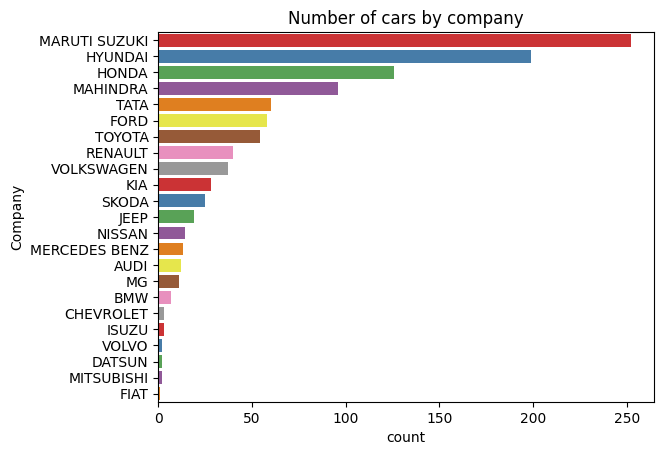

In [76]:
#Number of cars by company
sns.countplot(df['Company'],order=df['Company'].value_counts().index, palette = 'Set1').set_title('Number of cars by company')

This graph shows how used cars from different companies are distributed in the dataset. There are 23 companies in total, but most of the cars listed for sale come from just a few major brands—Maruti Suzuki, Hyundai, Honda, Mahindra, and Tata. This suggests that cars from these companies are not only more popular but also more durable and hold their value better over time.

### Top 10 Car Models

Text(0.5, 1.0, 'Top 10 Car Models')

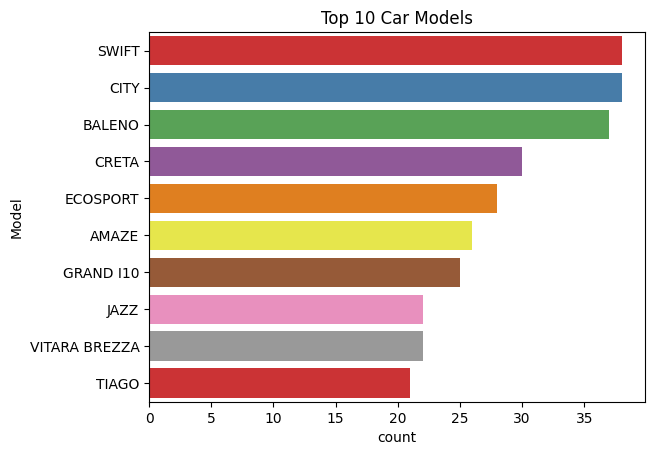

In [77]:
#Top 10 cars models by number
sns.countplot(df['Model'],order=df['Model'].value_counts().iloc[:10].index, palette = 'Set1').set_title('Top 10 Car Models')

The Honda City and Swift are the top two car models in the dataset, with the Baleno, Creta, and EcoSport following closely behind. This suggests that these models are not only known for their durability but also tend to hold their value well in the resale market. Additionally, the graph shows that the Honda City and Swift are in particularly high demand when it comes to used cars.

### Car Fuel Type

Text(0.5, 1.0, 'Number of cars by Fuel Type')

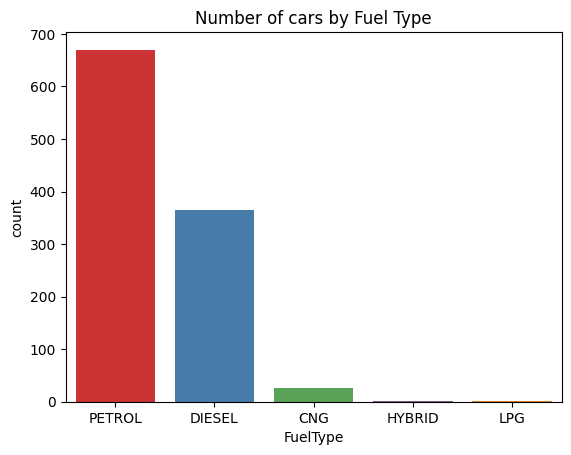

In [78]:
#Cars count by fuel type
sns.countplot(x = 'FuelType', data = df, palette = 'Set1').set_title('Number of cars by Fuel Type')

Most of the cars listed for resale have petrol engines, with over 650 cars in this category, followed by around 350 cars with diesel engines. There are only a few cars with CNG engines, and very few hybrid or LPG cars available. This suggests that petrol and diesel cars are the most in demand in the used car market.

### Top 10 Colors for Cars

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'White'),
  Text(1, 0, 'Silver'),
  Text(2, 0, 'Grey'),
  Text(3, 0, 'Red'),
  Text(4, 0, 'Black'),
  Text(5, 0, 'Brown'),
  Text(6, 0, 'Blue'),
  Text(7, 0, 'A Blue'),
  Text(8, 0, 'Pearl White'),
  Text(9, 0, 'Orange')])

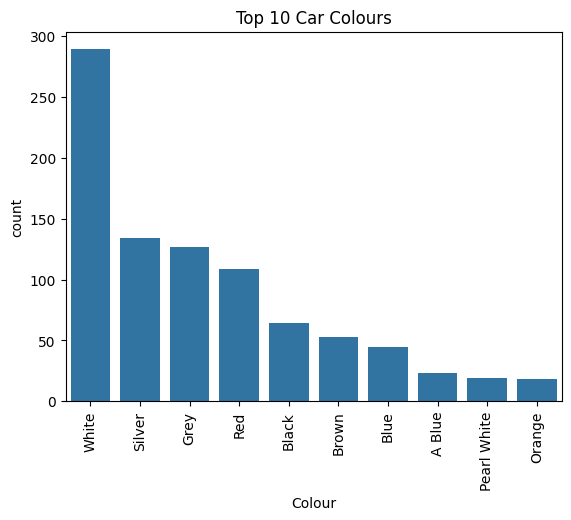

In [79]:
#Top 10 colors of cars
sns.countplot(x = 'Colour', data = df, order = df['Colour'].value_counts().iloc[:10].index).set_title('Top 10 Car Colours')
plt.xticks(rotation = 90)

Although color of car has no impact on the cars performance, but still it plays a major role in the car demand. From the graph, we can see that white color is the most preferred color for the used cars, followed by silver, grey, red and black. Therefore, we can assume that white, silver, grey, red and black color cars are more in demand in the used car market will have a good resale value.

### Odometre Reading

Text(0.5, 1.0, 'Odometer Reading')

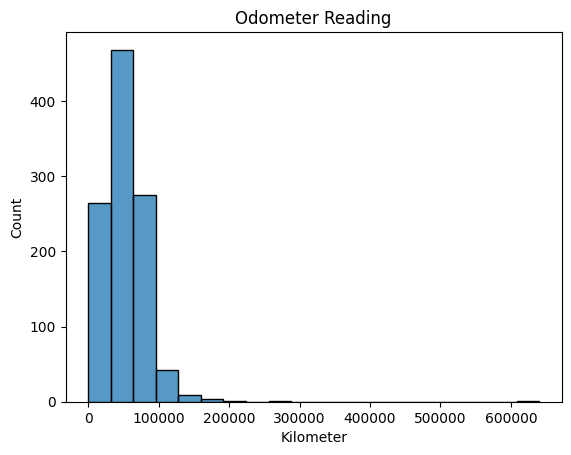

In [80]:
#Odometer reading distribution
sns.histplot(x = 'Kilometer', data = df, bins = 20).set_title('Odometer Reading')

This graph shows the distribution of the odometer readings of the cars in the dataset. From the graph, we can see that most of the cars have odometer reading less than 100000 km. To be more particular majority of cars are driven for 30000 km to 50000 km. Thefore, we can assume that cars with odometer reading less than 100000 km are more in demand in the used car market will have a good resale value.

### Body Style

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'HATCHBACK'),
  Text(1, 0, 'SEDAN'),
  Text(2, 0, 'MPV'),
  Text(3, 0, 'SUV'),
  Text(4, 0, 'HATCHBACK '),
  Text(5, 0, 'VAN'),
  Text(6, 0, 'MUV'),
  Text(7, 0, 'COMPACTSUV'),
  Text(8, 0, 'Sedan'),
  Text(9, 0, 'SUV ')])

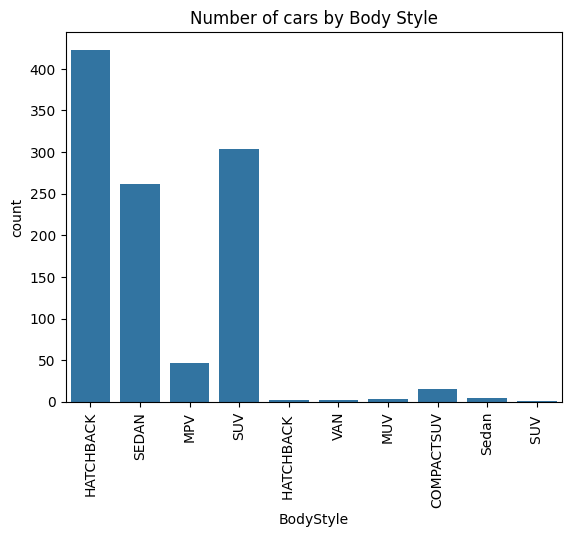

In [81]:
#Body style count
sns.countplot(x = 'BodyStyle', data = df).set_title('Number of cars by Body Style')
plt.xticks(rotation = 90)

According to this graph, most of the cars have HatchBack, SUV and Sedan body style, which tells us about the market demand of these body styles. Therefore, we can assume that cars with HatchBack, SUV and Sedan body style are more in demand in the used car market will have a good resale value.

### Car Age Distribution

Text(0.5, 1.0, 'Car age distribution')

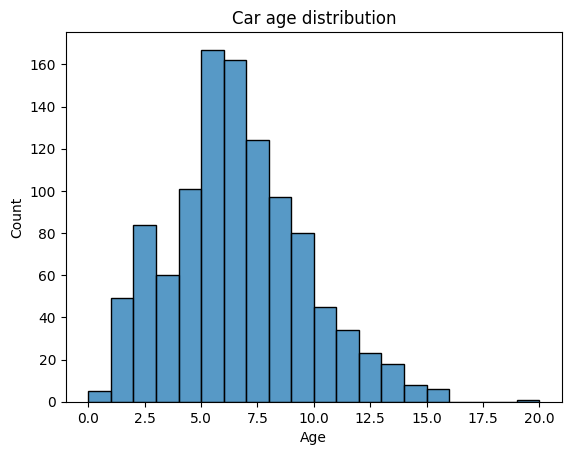

In [82]:
#Car age distribution
sns.histplot(x = 'Age', data = df, bins = 20).set_title('Car age distribution')

Age of the car plays an important role in deciding its resale value. Here, in the dataset cars that age between 5 to 7 years are more in number. Moreover majority of the cars age more than 5 years, which affect their resale value. However, there are still significant number of cars with age less than 5 years, thereofore, I assume they would have higher resale value.

In addition to that, we can see than one car has age near 20 years which could be an outlier.

### Price Distribution

Text(0.5, 1.0, 'Car price distribution')

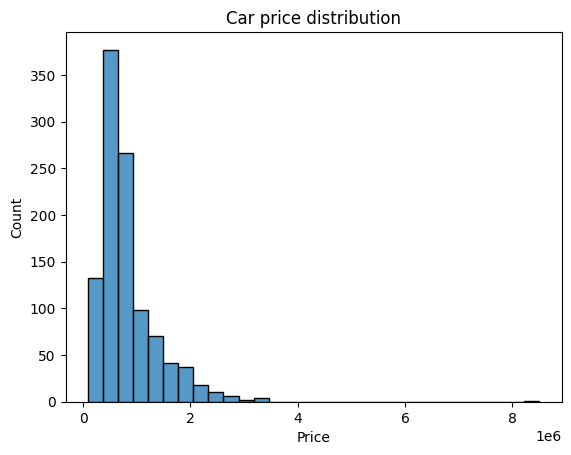

In [83]:
#Price distribution
sns.histplot(x = 'Price', data =df, bins = 30).set_title('Car price distribution')

This graph help us to know about the distribution of the car prices in the dataset. In the dataset, most of the cars have price is between 3 to 9 lakhs, with maximum cars between 3 to 6 lakhs. Therefore, we can assume that cars with price between 3 to 9 lakhs are more in demand in the used car market. Moreover there are some cars with resale price more than 20 lakhs, which could be possible for luxury cars or it could be an outlier.

### Location based Distribution

[Text(0, 0, 'Car Choice Exclusif'),
 Text(1, 0, 'Car&Bike Superstore Pune'),
 Text(2, 0, 'Prestige Autoworld Pvt Ltd'),
 Text(3, 0, 'Star Auto India'),
 Text(4, 0, 'Noida Car Ghar'),
 Text(5, 0, 'Top Gear Cars'),
 Text(6, 0, 'Car Estate'),
 Text(7, 0, 'OM Motors'),
 Text(8, 0, 'Jeen Mata Motors'),
 Text(9, 0, 'Royal Motors (Prop. Auto Carriage Pvt Ltd)')]

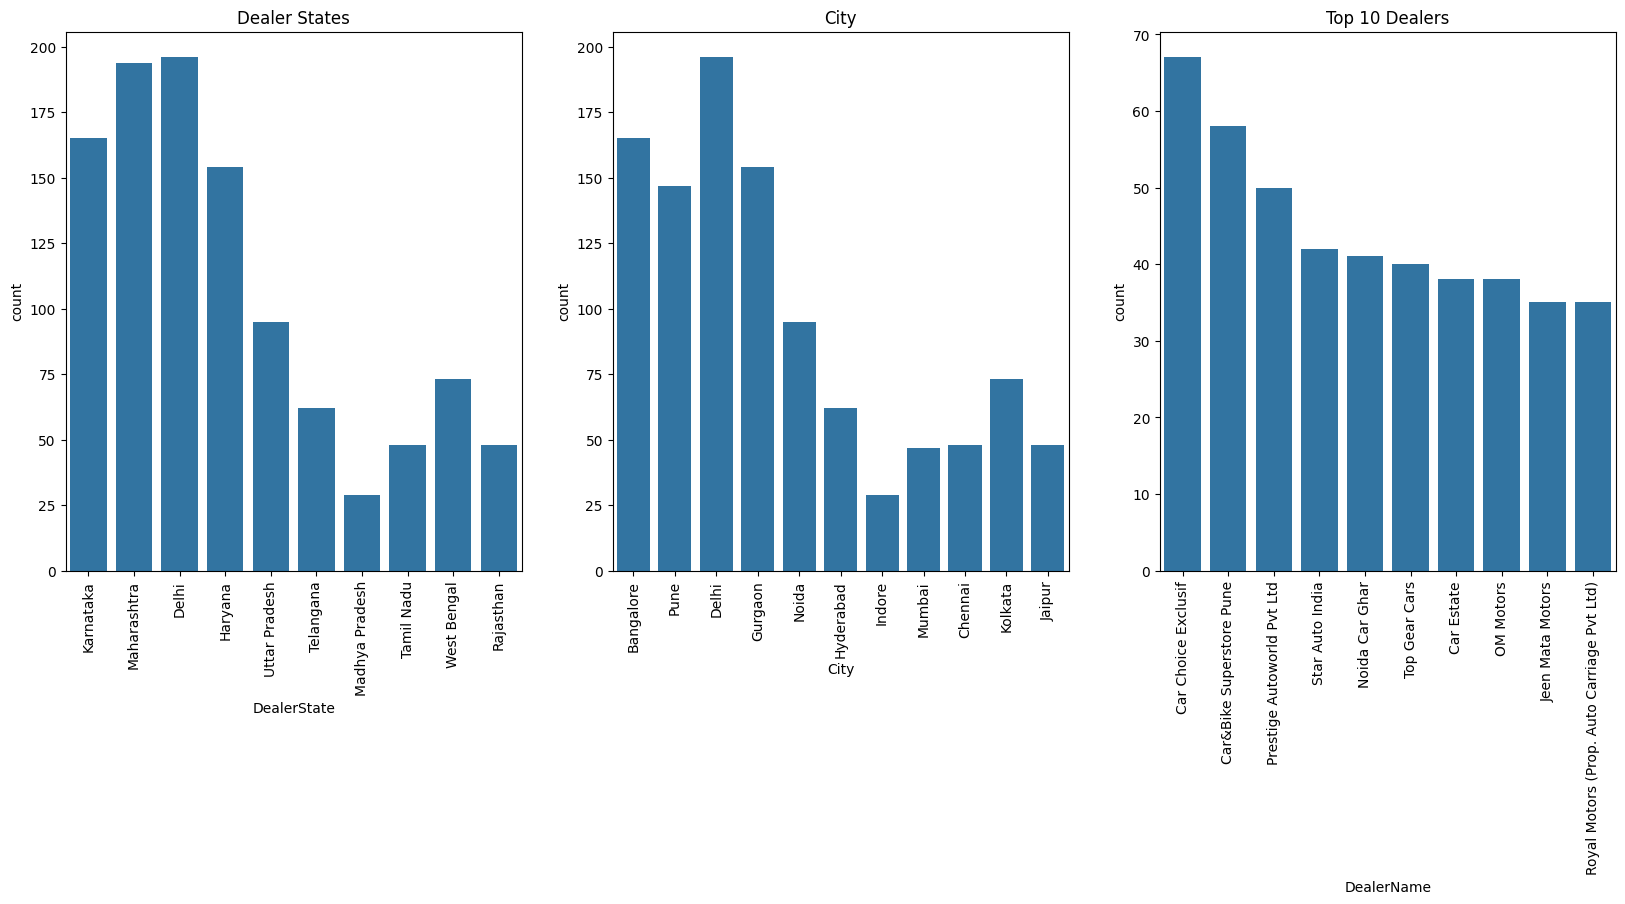

In [84]:
fig, ax = plt.subplots(1,3,figsize=(20,7))

#Dealer State
sns.countplot(x = 'DealerState', data = df, ax = ax[0]).set_title('Dealer States')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)

#City
sns.countplot(x = 'City', data = df, ax = ax[1]).set_title('City')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 90)

#top 10 dealers
sns.countplot(x = 'DealerName', data = df, order = df['DealerName'].value_counts().iloc[:10].index, ax = ax[2]).set_title('Top 10 Dealers')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation = 90)

These graphs shows the distribution of cars based on their dealer state, city and Dealer Name. In the dealer state graph, we see that Delhi and Maharashtra have the highest number of used cars for sale followed by Karnataka and Haryana. In the dealer city graph, we see that Delhi has the highest number of cars which is obvious from the the previous graph, however in contrast to the previous graph, Banglore has more used cars for sale than Pune, infact Pune has lower car count than Gurgaon. In the dealer name graph, we see that Car Choice Exclusif, Car&Bike Superstore Pune and Prestige Autoworld Pvt Ltd are moung the top 3 dealers with highest number of used cars for sale.

### Car Owner Type

Text(0.5, 1.0, 'Number of cars by Owner Type')

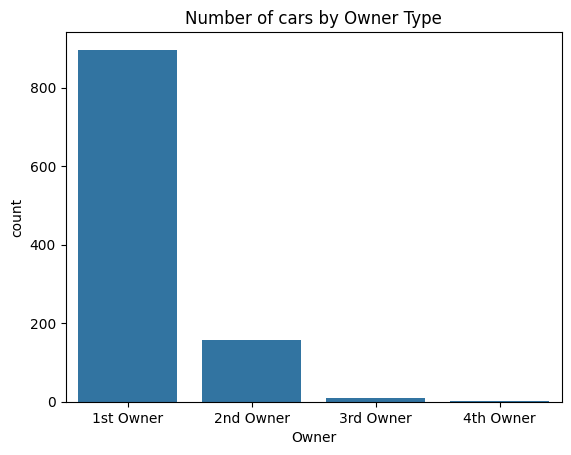

In [85]:
sns.countplot(x = 'Owner', data = df).set_title('Number of cars by Owner Type')

The car owner type has a huge impact on its resale value. Majority of the cars that are been sold are 1at Owner cars followed by 2nd Owner cars which are significantly less in number as compared to 1st Owner. Moreover, the 3rd and 4th owner cars are very less in number. Therefore, we can assume that 1st Owner cars are more preferred in the used car market and have a good resale value.

### Warranty

Text(0.5, 1.0, 'Number of cars by Warranty')

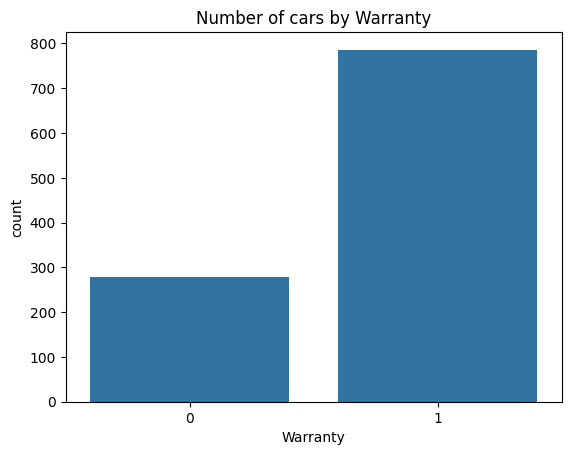

In [86]:
sns.countplot(x = 'Warranty', data = df).set_title('Number of cars by Warranty')

This graphs shows the number of used cars for sale that come with a warranty from the dealership company. The warranty plays a major role and customers prefer to purchase a car with warranty, it has been shown in the dataset as well, where we can see than the number cars with warranty is almost twice the number of cars without warranty.

### Quality Score Distribution

Text(0.5, 1.0, 'Quality Score Distribution')

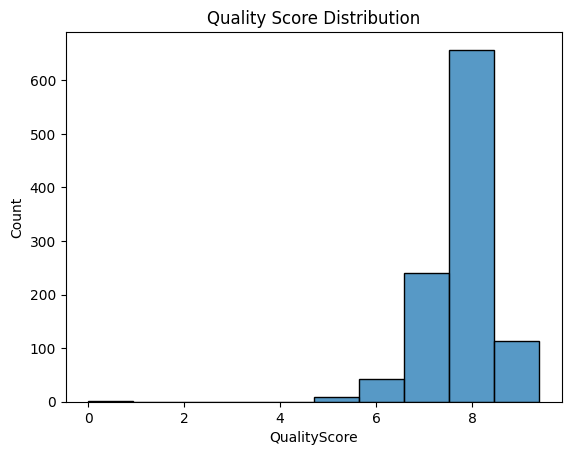

In [87]:
sns.histplot(x = 'QualityScore', data = df, bins = 10).set_title('Quality Score Distribution')

Quality score is an important feature which has a huge impact on the car sales and its preference by the customers. Cars with higher quality scores tend to have a much higher resale value and are more preferred by the customers. In the dataset, most of the cars have a decent quality score between 7-8, which highlights that the cars are thoroughly checked before being sold in the used car market. However, there are some cars with quality score less than 5, which could be due to the fact that they are not in good condition or they are very old.

##### Till now, I have visualized the distribution of the data and got a better understanding of the data. Now, I will be looking at the relationship between the Car Price aans the independent variables.

### Top 10 Car Companies by Price

Text(0.5, 1.0, 'Top 10 car Companies by price')

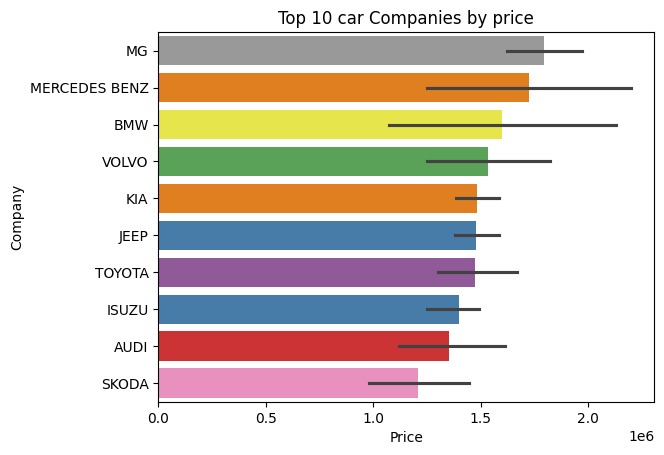

In [88]:
#Top 10 car companies by price
sns.barplot(y = 'Company', x = 'Price', data = df, order = df.groupby('Company')['Price'].mean().sort_values(ascending=False).iloc[:10].index, hue = 'Company', palette= 'Set1').set_title('Top 10 car Companies by price')

This graphs highlights the top 10 car companies in the dataset with the highest resale value. The MG, Mercedes Benz and BMW are the top 3 car companies with the highest resale value, since these are luxury car companies. The list also includes Volvo. followed by KIA, Jeep and Toyota. Surprisingly Audi has much lower resale price has compared to the other luxury car companies which might be due to other features.

Moreover, my prevous hypothesis, about the car companies -Maruti Suzuki, Hyundai, Honda, Mahindra and Tata, was wrong as they are not in the top 10 list. This means that these companies cars are in greater number due to their demand because of low price

### Top 10 Car Models by Price

Text(0.5, 1.0, 'Top 10 car Models by price')

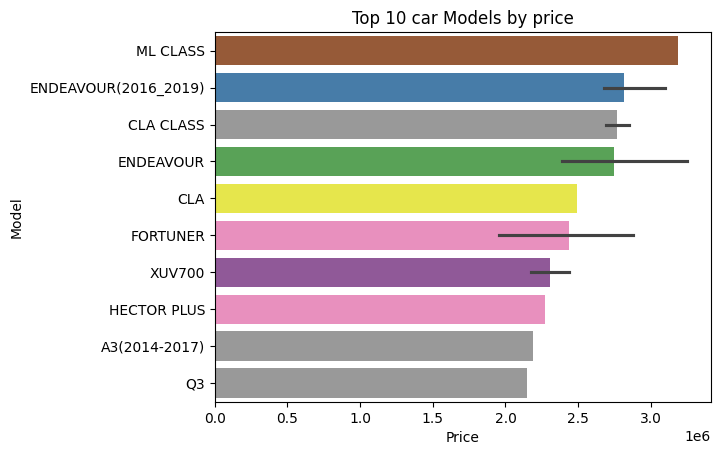

In [89]:
#Top 10 car models by price
sns.barplot(y = 'Model', x = 'Price', data = df, order = df.groupby('Model')['Price'].mean().sort_values(ascending=False).iloc[:10].index, hue = 'Model', palette= 'Set1').set_title('Top 10 car Models by price')

This graph shows the relation between the car model and it resale value and we can see that it shows similarity woth the previous graph. The car models - ML Class, Endeavour(2016_2019), CLA class are the top three models with highest resale value, followed by CLA, Fortuner and XUV700. Like the previous graph, the audi model A3 is at the 9th position with a much lower resale value as compared to the other models.

In the car model also my hypothesis was wrong as I assummed that Honda City and Swift are the top two car models in the dataset, followed by Baleno, Creata and EcoSport. Therefore, we came to know that these car in higher number due to their high demnad because of low price.

### Car Fuel Type and Price

Text(0.5, 1.0, 'Price by Fuel Type')

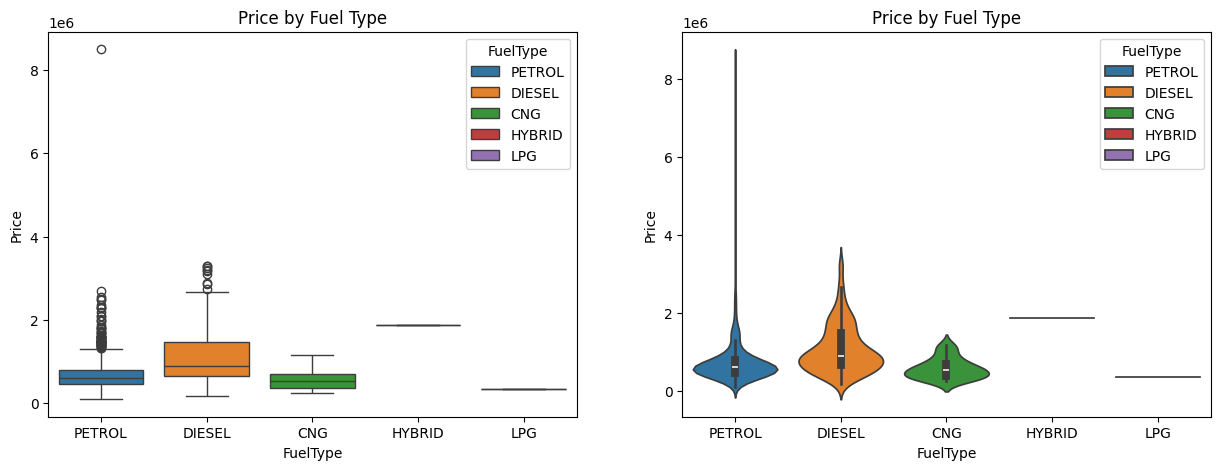

In [90]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.boxplot(x = 'FuelType', y = 'Price', data = df, ax = ax[0], hue = 'FuelType').set_title('Price by Fuel Type')
sns.violinplot(x = 'FuelType', y = 'Price', data = df, ax = ax[1], hue = 'FuelType').set_title('Price by Fuel Type')

The above plots visualizes the relationship between the car fuel type and its resale value. In the boxplot we can see than cars with diesel fuel type have higher resale value than petrol and CNG and LPG. In the violin plot, we can see that the distribution of the price for diesel cars is more concentrated between 10 to 20 lakh as compared to Petrol. From this it is cleared that, customers prefer petrol and diesel car than other fuel type and the diesel cars are more in demand in the used car market.

### Top 10 Car Colors by Price

Text(0.5, 1.0, 'Top 10 car Colors by price')

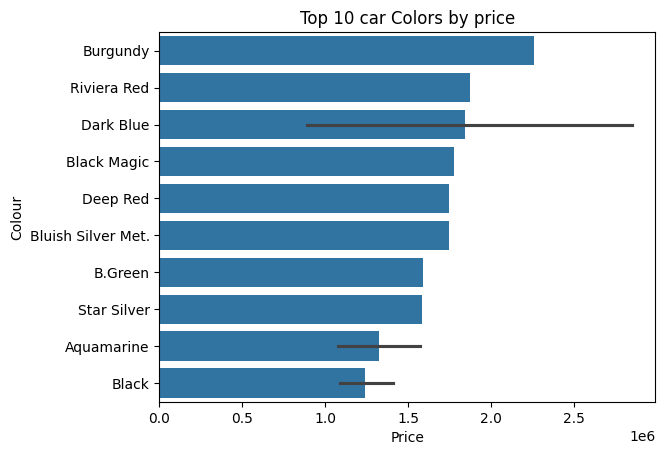

In [91]:
#Top 10 car colors by price
sns.barplot(y = 'Colour', x = 'Price', data = df, order = df.groupby('Colour')['Price'].mean().sort_values(ascending=False).iloc[:10].index).set_title('Top 10 car Colors by price')

The cars with colors like Burgundy, Riviera Red and Dark Blue have higher resale value as compared to other colors. This shows that color of the car does matter and plays a major role in the resale value of the car.

Moreover, we also came to know that exotic colors have more price but they are not in demand in the used car market.

### Odometer Reading and Price

Text(0.5, 1.0, 'Odometer Reading and Price')

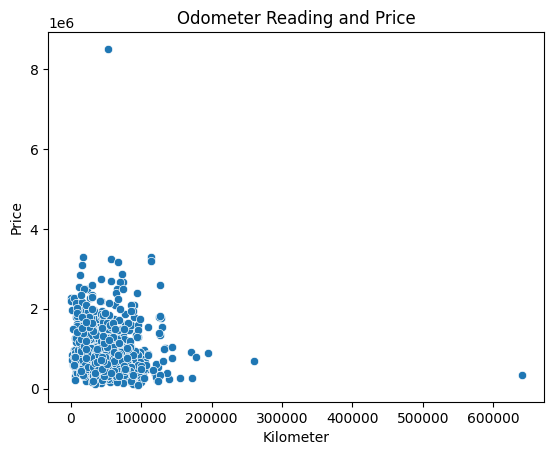

In [92]:
sns.scatterplot(x = 'Kilometer', y = 'Price', data = df).set_title('Odometer Reading and Price')

In the scatter plot we can see than the data is concentrated near the origin, which means that most of the cars have odometer reading less than 100000 km. In addition to that the cars with less odometer reading shows higher resale value and as the odometer reading increases the resale value decreases. Therefore, my hypothesis was correct that cars with odometer reading less than 100000 km are more in demand in the used car market will have a good resale value.

### Body Style and Price

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'HATCHBACK'),
  Text(1, 0, 'SEDAN'),
  Text(2, 0, 'MPV'),
  Text(3, 0, 'SUV'),
  Text(4, 0, 'HATCHBACK '),
  Text(5, 0, 'VAN'),
  Text(6, 0, 'MUV'),
  Text(7, 0, 'COMPACTSUV'),
  Text(8, 0, 'Sedan'),
  Text(9, 0, 'SUV ')])

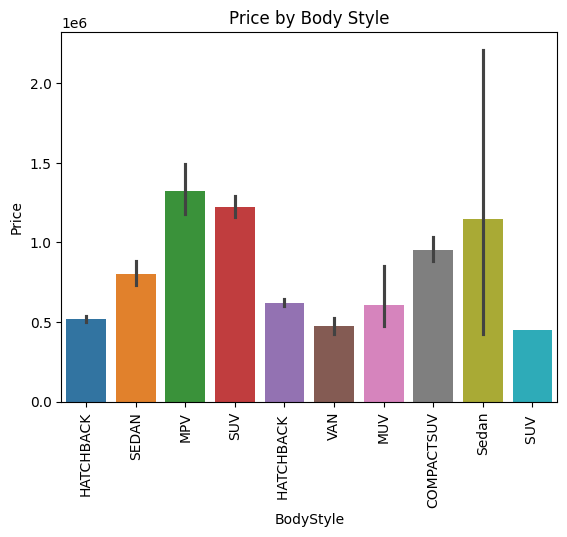

In [93]:
sns.barplot(x = 'BodyStyle', y = 'Price', data = df, hue = 'BodyStyle').set_title('Price by Body Style')
plt.xticks(rotation = 90)

MPV, SUV and Sedan are the top 3 car body styles with the highest resale value. Therefore, we can assume that these body styles are more preferred in the used car market and have a good resale value. This also shows that my assumption was correct however, the Hatchback body style cars despite being in majority have lower resale value.

### Car Age and Price

Text(0.5, 1.0, 'Car age and Price')

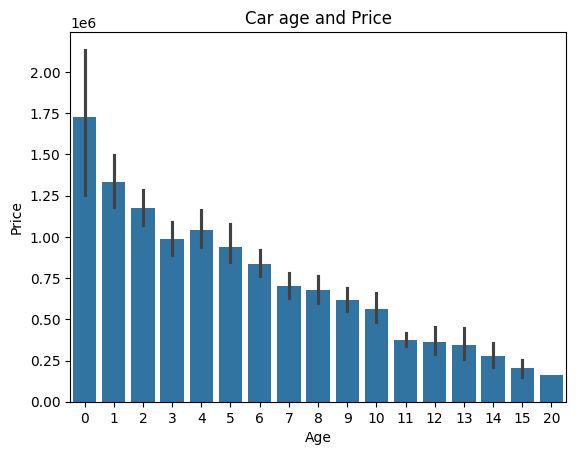

In [94]:
sns.barplot(x = 'Age', y = 'Price', data = df).set_title('Car age and Price')

As we discussed earlier, age is a key determinant for a car's resale value and this graph clearly visulaizes the relation of the age with car price. The cars with age less than a year has then highest price and as the age increases the prices decreases gradually. Therefore, my hypothesis was correct that cars with age less than 5 years have higher resale value.

### Location based Price Distribution

[Text(0, 0, 'Car Choice Exclusif'),
 Text(1, 0, 'Car&Bike Superstore Pune'),
 Text(2, 0, 'Prestige Autoworld Pvt Ltd'),
 Text(3, 0, 'Star Auto India'),
 Text(4, 0, 'Noida Car Ghar'),
 Text(5, 0, 'Top Gear Cars'),
 Text(6, 0, 'Car Estate'),
 Text(7, 0, 'OM Motors'),
 Text(8, 0, 'Jeen Mata Motors'),
 Text(9, 0, 'Royal Motors (Prop. Auto Carriage Pvt Ltd)')]

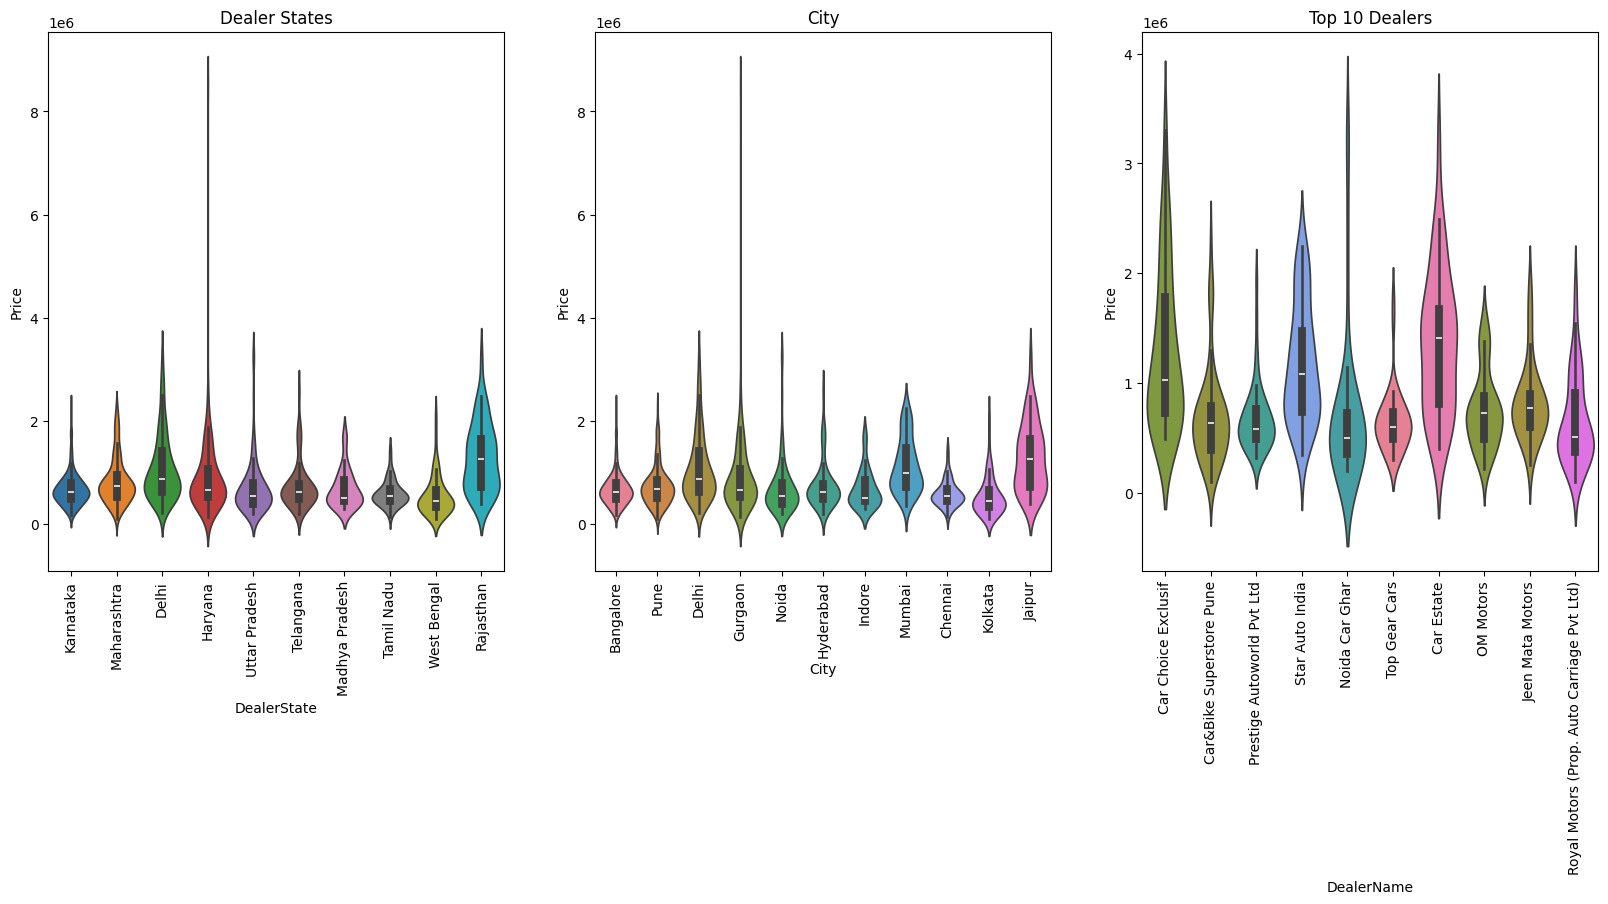

In [95]:
fig, ax = plt.subplots(1,3,figsize=(20,7))

#Dealer State
sns.violinplot(x = 'DealerState', y = 'Price', data = df, ax = ax[0], hue = 'DealerState').set_title('Dealer States')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 90)

#City
sns.violinplot(x = 'City',y = 'Price', data = df, ax = ax[1], hue = 'City').set_title('City')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 90)

#top 10 dealers
sns.violinplot(x = 'DealerName',y = 'Price', data = df, order = df['DealerName'].value_counts().iloc[:10].index, ax = ax[2], hue = 'DealerName').set_title('Top 10 Dealers')
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation = 90)

In the above graph we can see the price distribution based on the state, city and the dealer name. In the state graph, we can see that the cars in Rajastan have the highest price followed by Delhi. Moreover, there are some outliers in the graph which os visible from the violinplot where there is strong peak incase of Haryana. In the city graph, we can see that the cars in Jaipur have the highest price followed by Mumbai and Delhi. Moreover, there are some outliers in the graph which os visible from the violinplot where there is strong peak incase of Gurgaon. In the dealer name graph, we can see the top 10 dealers along with their price distribution. Here, Car Estate has the highest price followed by Star Auto India and Car Choice. Moreover, there are some outliers in the graph which os visible from the violinplot where there is strong peak incase of Noida Car Ghar.

### Car Owner Type and Price

Text(0.5, 1.0, 'Price by Owner Type')

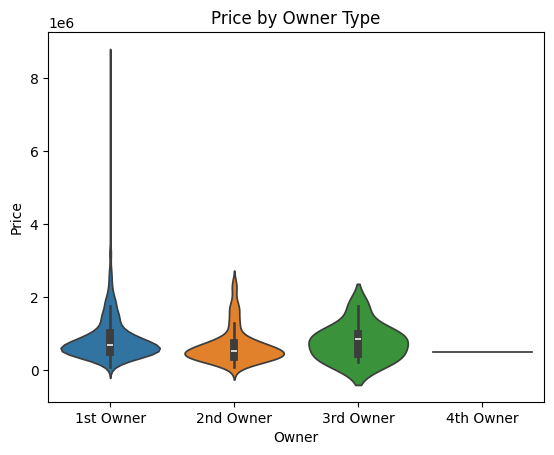

In [96]:
sns.violinplot(x = 'Owner', y = 'Price', data = df, hue = 'Owner').set_title('Price by Owner Type')

The graph shows the price distribution with respect to the car owner type. The cars with 1st owner have the highest price which is obvious as they are new cars. However, the 3rd Owner type cars depite being less in number have higher price than 2nd Owner type cars, which is not obvious. Therefore, we can assume that 3rd Owner type cars having higher price could some luxury or vintage cars.

### Warranty and Price

Text(0.5, 1.0, 'Price by Warranty')

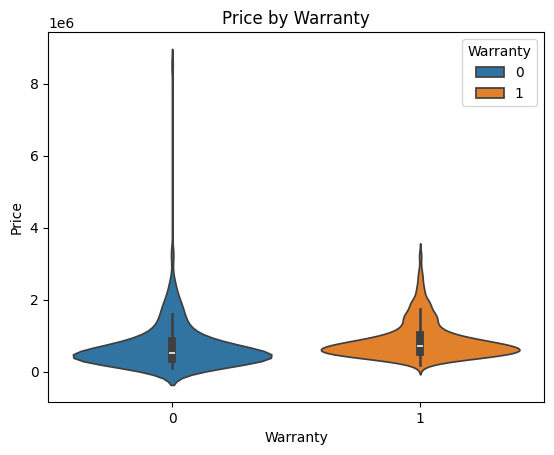

In [97]:
sns.violinplot(x = 'Warranty', y = 'Price', data = df, hue = 'Warranty').set_title('Price by Warranty')

Here, we can see some change in the violinplot of the cars with and without warranty. The cars with warranty tends to have slightly higher price than the cars without warranty. Therefore, we can assume that cars with warranty are more preferred in the used car market and have a good resale value.

### Quality Score and Price

Text(0.5, 1.0, 'Quality Score and Price')

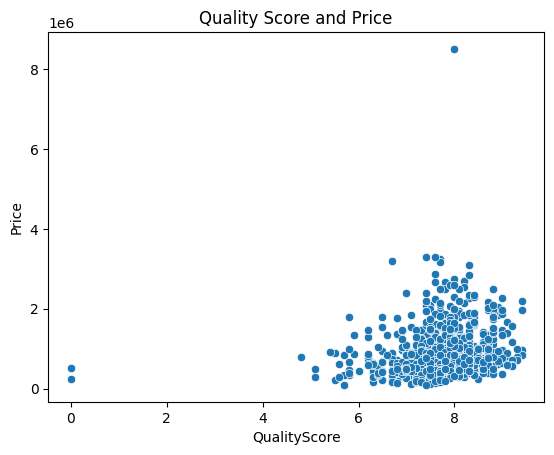

In [98]:
sns.scatterplot(x = 'QualityScore', y = 'Price', data = df).set_title('Quality Score and Price')

We can see a very high concentration near the quality score 7 and above having much higher price than the cars with quality score less than 7. Therefore, we can assume that cars with quality score 7 and above are more preferred in the used car market and have a good resale value.

## Data Preprocessing Part 2

Dropping column car model beacause, it has too many unique values and it will increase the dimensionality of the dataset.

In [99]:
df.drop('Model', axis = 1, inplace = True)

### Label Encoding

In [100]:
#columns for label encoding
cols = df.select_dtypes(include=['object']).columns

from sklearn.preprocessing import LabelEncoder
#Label encoding object
le = LabelEncoder()

#label encoding for object type columns
for i in cols:
    le.fit(df[i])
    df[i] = le.transform(df[i])
    print(i, df[i].unique())

Company [12  7 19  5 13 21 11  6 17 16  9  4 20 10  1  3 18 14  0  8 22 15  2]
FuelType [4 1 0 2 5 3]
Colour [61 56 34  0  9 11 66 47 49 38 14 71 72 30 74 52 39 28 60  7 54 62 40 13
 20 70 63 12 24 23 35 26 29 15 31  1 68  4  8 73 22 44 57 65 42 50 32 64
 19 43 46 33 16 27 53 25 10 69 51 17  6 48 59 58  5  3 18 45 67 36 21 55
  2 37 75 41]
BodyStyle [1 5 3 6 2 9 4 0 8 7]
Owner [0 1 2 3]
DealerState [2 4 0 1 8 7 3 6 9 5]
DealerName [52 38  4  1 56 29  0 34 47 51 11 21  9 10 43 33  7 16  5 12 42 17 27 50
 45  6 20 36 23 41 32 31 18  2 48 15 54 40 55 13 49 25 35 46 24 14 44 19
 39 28 26  3 53 30  8 22 37]
City [ 0 10  2  3  9  4  5  8  1  7  6]


### Outlier Removal

In [101]:
#Using IQRS to remove outliers

#columns for outlier removal
cols = df.select_dtypes(include=['int64','float64']).columns
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)

IQR = Q3 - Q1

#Removing outliers
df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Correlation Matrix Heatmap

<Axes: >

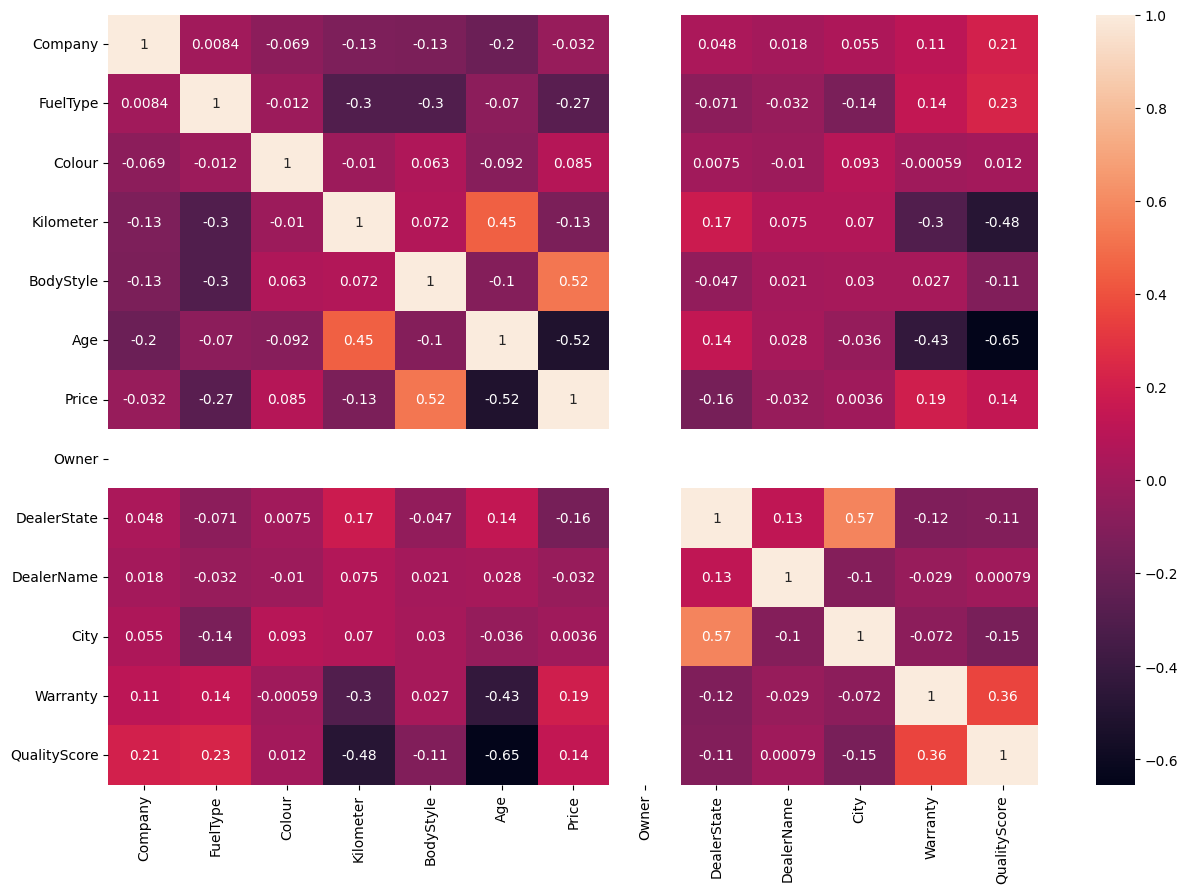

In [102]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True)

## Train Test Split

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Price',axis=1), df['Price'], test_size=0.2, random_state=42)

## Model Building

I will be using the following regression models:
- Decision Tree Regressor
- Random Forest Regressor
- Ridge Regressor

### Decision Tree Regressor

In [104]:
from sklearn.tree import DecisionTreeRegressor
#Decision Tree Regressor Object
dtr = DecisionTreeRegressor()

#### Hyperparameter Tuning

In [105]:
from sklearn.model_selection import GridSearchCV

#parameters for grid search
para = {
    'max_depth' : [2,4,6,8],
    'min_samples_leaf' : [2,4,6,8],
    'min_samples_split' : [2,4,6,8],
    'random_state' : [0,42]
}

#Grid Search Object
grid = GridSearchCV(estimator=dtr, param_grid=para, cv=5, n_jobs=-1, verbose=2)

#Fitting the model
grid.fit(X_train, y_train)

#Best parameters
print(grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
{'max_depth': 6, 'min_samples_leaf': 4, 'min_samples_split': 2, 'random_state': 0}


In [106]:
#decision tree regressor with best parameters
dtr = DecisionTreeRegressor(max_depth=6, min_samples_leaf=2, min_samples_split=2, random_state=42)

#Fitting the model
dtr.fit(X_train, y_train)

#Training score
print(dtr.score(X_train, y_train))

0.7709748363868894


In [107]:
#Prediction
dtr_pred = dtr.predict(X_test)

### Random Forest Regressor

In [108]:
from sklearn.ensemble import RandomForestRegressor
#Random Forest Regressor Object
rfr = RandomForestRegressor()

#### Hyperparameter Tuning

In [53]:
from sklearn.model_selection import GridSearchCV

#parameters for grid search
para = {
    'max_depth' : [2,4,6,8],
    'min_samples_leaf' : [2,4,6,8],
    'min_samples_split' : [2,4,6,8],
    'random_state' : [0,42]
}

#Grid Search Object
grid = GridSearchCV(estimator=rfr, param_grid=para, cv=5, n_jobs=-1, verbose=2)

#Fitting the model
grid.fit(X_train, y_train)

#Best parameters
print(grid.best_params_)

Fitting 5 folds for each of 128 candidates, totalling 640 fits
{'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'random_state': 0}


In [54]:
#Random Forest Regressor with best parameters
rfr = RandomForestRegressor(max_depth=8, min_samples_leaf=2, min_samples_split=2, random_state=0)

#Fitting the model
rfr.fit(X_train, y_train)

#Training score
print(rfr.score(X_train, y_train))

0.8922093892033637


In [55]:
#Prediction
rfr_pred = rfr.predict(X_test)

## Model Evaluation

### Distribution Plot

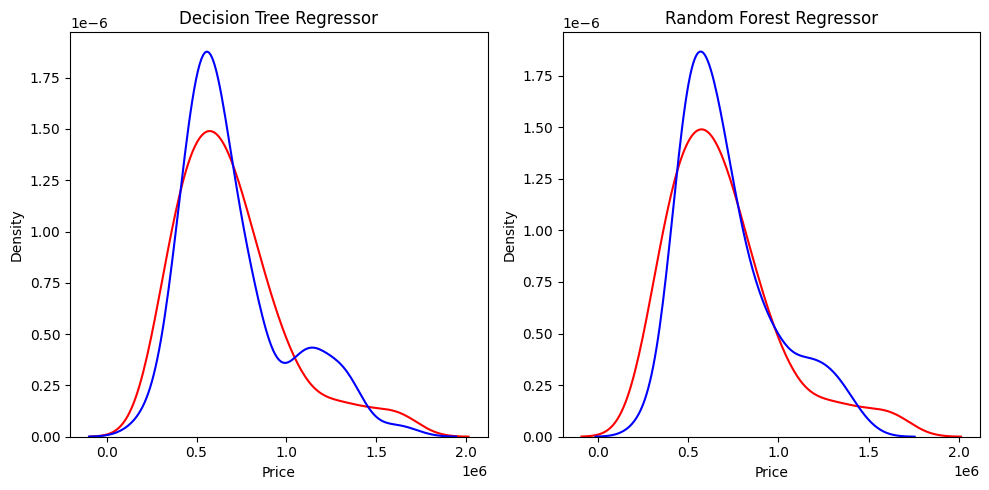

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Decision tree regressor
sns.kdeplot(x=y_test, ax=ax[0], color='r', label='Actual', fill=False).set_title('Decision Tree Regressor')
sns.kdeplot(x=dtr_pred, ax=ax[0], color='b', label='Predicted', fill=False)

# Random forest regressor
sns.kdeplot(x=y_test, ax=ax[1], color='r', label='Actual', fill=False).set_title('Random Forest Regressor')
sns.kdeplot(x=rfr_pred, ax=ax[1], color='b', label='Predicted', fill=False)

plt.tight_layout()
plt.show()


### Model Metrics

In [57]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#Decision Tree Regressor
print('Decision Tree Regressor')
print('Mean Squared Error : ', mean_squared_error(y_test, dtr_pred))
print('Mean Absolute Error : ', mean_absolute_error(y_test, dtr_pred))
print('R2 Score : ', r2_score(y_test, dtr_pred))

#Random Forest Regressor
print('Random Forest Regressor')
print('Mean Squared Error : ', mean_squared_error(y_test, rfr_pred))
print('Mean Absolute Error : ', mean_absolute_error(y_test, rfr_pred))
print('R2 Score : ', r2_score(y_test, rfr_pred))

Decision Tree Regressor
Mean Squared Error :  45585786671.20511
Mean Absolute Error :  143988.5965345904
R2 Score :  0.5044410153036336
Random Forest Regressor
Mean Squared Error :  28952122030.700592
Mean Absolute Error :  122585.28783370154
R2 Score :  0.6852640867684735


## Feature Importance

Text(0.5, 1.0, 'Random Forest Regressor')

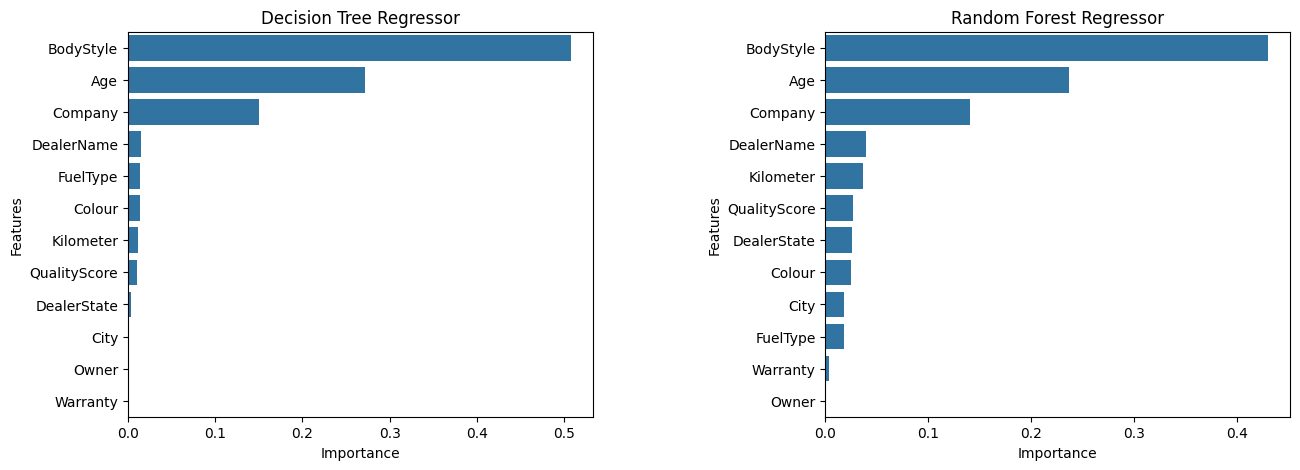

In [58]:
fig, ax = plt.subplots(1,2,figsize=(15, 5))
fig.subplots_adjust(wspace=0.5)

#Decision Tree Regressor
feature_df = pd.DataFrame({'Features':X_train.columns, 'Importance':dtr.feature_importances_})
feature_df.sort_values(by='Importance', ascending=False, inplace=True)
sns.barplot(x = 'Importance', y = 'Features', data = feature_df, ax = ax[0]).set_title('Decision Tree Regressor')

#Random Forest Regressor
feature_df = pd.DataFrame({'Features':X_train.columns, 'Importance':rfr.feature_importances_})
feature_df.sort_values(by='Importance', ascending=False, inplace=True)
sns.barplot(x = 'Importance', y = 'Features', data = feature_df, ax = ax[1]).set_title('Random Forest Regressor')

## Conclusion



---

### 1. **Demand and Price Trends**
   - **High Demand for Budget Cars**: There’s a clear trend in the used car market where low-priced cars have significantly higher demand compared to expensive ones. This points to a customer preference for budget-friendly vehicles, which is an essential factor to consider in the market.

### 2. **Car Brands and Their Impact on Demand and Price**
   - **Luxury Brands vs. Budget Brands**:
     - Luxury brands like **MG**, **Mercedes Benz**, **BMW**, **Volvo**, and **KIA** have higher price tags.
     - On the other hand, brands such as **Maruti Suzuki**, **Hyundai**, **Honda**, **Mahindra**, and **Tata** see higher demand in the used car market.
   - **Insight**: Consumers tend to prefer purchasing new luxury cars instead of buying used luxury vehicles, highlighting the appeal of new models in high-end segments.

### 3. **Fuel Type and Its Effect on Pricing**
   - **Petrol and Diesel Cars**:
     - The majority of cars in the market run on **petrol** or **diesel**, with **diesel cars** being priced slightly higher due to perceived better fuel efficiency and longevity.
   - **Conclusion**: The fuel type remains a significant factor in determining car pricing, with diesel cars holding a price advantage.

### 4. **Car Color and Its Influence on Pricing and Demand**
   - **Most Popular Colors**:
     - **White**, **grey**, **silver**, and **black** are the most demanded colors in the used car market.
   - **Exotic Colors and Price**:
     - Cars in more exotic colors like **burgundy**, **riviera red**, **dark blue**, and **black magic** are priced higher, despite not being as popular in terms of demand.
   - **Takeaway**: Color plays a dual role, affecting both customer attraction and pricing, with more unique colors commanding a premium.

### 5. **Odometer Reading and Pricing Trends**
   - **Cars with Lower Mileage**:
     - Most cars in the market have an **odometer reading of less than 10,000 km**, which correlates with higher prices.
   - **Lower Mileage Equals Higher Price**:
     - The general rule is that cars with lower mileage are priced higher due to better perceived condition and less wear and tear.

### 6. **Body Style Preference**
   - **Most Preferred Body Styles**:
     - **Hatchback**, **SUV**, and **Sedan** are the most popular body styles among customers.
   - **Most Expensive Body Styles**:
     - **MPV** (Multi-Purpose Vehicle), **SUV**, and **Sedan** dominate the high-end pricing segment.
   - **Insight**: Customers tend to prefer more compact or practical body styles, while larger vehicles or specific body styles like MPVs tend to have higher price points.

### 7. **Age of the Car and Its Impact on Resale Value**
   - **Impact of Age on Price**:
     - As the car's **age increases**, its **resale value** decreases. Cars less than **5 years old** are in high demand and command higher prices.
   - **Conclusion**: Younger cars are significantly more valuable in the used car market, reflecting better condition and newer technology.

### 8. **Location-Based Price Variations**
   - **Top States with Highest Prices**:
     - **Delhi**, **Maharashtra**, and **Rajasthan** have the highest car prices, which can be attributed to demand, economic conditions, and the presence of affluent buyers.
   - **Top Dealers**:
     - **Car Estate**, **Star Auto India**, and **Car Choice** are the leading dealers, often offering cars at a higher price due to brand reputation and vehicle quality.

### 9. **Owner Type and Its Effect on Demand and Pricing**
   - **First Owner Preference**:
     - **First-owner cars** are preferred, resulting in higher demand and consequently, higher prices.
   - **Customer Assurance**:
     - Buyers associate first-owner cars with better maintenance, further enhancing their value.

### 10. **Warranty and Quality Score**
   - **Warranty Influence**:
     - Cars with an **extended warranty** tend to fetch a slightly higher price due to the assurance of future reliability.
   - **Quality Score Impact**:
     - A higher **quality score** on a vehicle often translates into a higher asking price, as it indicates the car’s good condition and less potential for future repairs.

### 11. **Machine Learning Model Analysis**
   - **Models Used**:
     - **Decision Tree Regressor** and **Random Forest Regressor** were employed to predict car prices.
   - **Performance Comparison**:
     - The **Random Forest Regressor** outperformed the **Decision Tree Regressor** in terms of predictive accuracy and reliability.
   - **Key Features Affecting Car Price**:
     - According to the **feature importance** graph, the most influential factors in predicting car price are:
       - **Car age**
       - **Body style**
       - **Car company** (Brand)
   - **Conclusion**: These features are critical in shaping car pricing in the used car market.

---

